In [1]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CONFIGURATION - Following El-Fiky et al. (2021) Paper
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Paper uses 224x224
BATCH_SIZE = 32   # Paper uses batch size 32
EPOCHS = 60       # Paper uses 60 epochs
LEARNING_RATE = 0.001  # Paper uses 0.001

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.001


In [3]:
# Cell 2: Dataset Configuration and Loading
BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"Loading balanced Pneumothorax dataset...")

# Load the balanced dataset CSV
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    exit(1)

# Display CSV structure
print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Use Binary_Label column (already created by dataset.py)
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

# Create full image paths
df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify images exist
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")
print(f"Balance ratio: 1:1")
print(f"\nDataset is ready for training!")

Loading balanced Pneumothorax dataset...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

First 3 rows:
        Image_Index                      Finding_Labels  Pneumothorax  \
0  00001974_002.png           Infiltration|Pneumothorax             1   
1  00012620_013.png  Atelectasis|Consolidation|Effusion             0   
2  00014870_000.png                  Consolidation|Mass             0   

                      Path  Binary_Label  
0  images\00001974_002.png             1  
1  images\00012620_013.png             0  
2  images\00014870_000.png             0  

=== Final Dataset Summary ===
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302 (50.0%)
Balance ratio: 1:1

Dataset is ready for training!


In [4]:
# Cell 4: Dataset Splitting with Stratification
# Path already exists from Cell 2, just use balanced_df directly
print(f"Dataset ready for splitting: {len(balanced_df)} samples")

# Stratified train-validation-test split (80/10/10)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['binary_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")
print(f"  Negative: {len(train_df) - train_df['binary_label'].sum():,} ({(len(train_df) - train_df['binary_label'].sum())/len(train_df)*100:.1f}%)")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")
print(f"  Negative: {len(val_df) - val_df['binary_label'].sum():,} ({(len(val_df) - val_df['binary_label'].sum())/len(val_df)*100:.1f}%)")

print(f"\nTest set: {len(test_df):,} samples")
print(f"  Positive: {test_df['binary_label'].sum():,} ({test_df['binary_label'].sum()/len(test_df)*100:.1f}%)")
print(f"  Negative: {len(test_df) - test_df['binary_label'].sum():,} ({(len(test_df) - test_df['binary_label'].sum())/len(test_df)*100:.1f}%)")

# Save splits
os.makedirs('./output', exist_ok=True)
test_df.to_csv('./output/pneumothorax_test_set.csv', index=False)
print("\n✓ Test set saved for final evaluation")

Dataset ready for splitting: 10604 samples

=== Dataset Splits (Stratified) ===
Training set: 8,483 samples
  Positive: 4,242 (50.0%)
  Negative: 4,241 (50.0%)

Validation set: 1,060 samples
  Positive: 530 (50.0%)
  Negative: 530 (50.0%)

Test set: 1,061 samples
  Positive: 530 (50.0%)
  Negative: 531 (50.0%)

✓ Test set saved for final evaluation


In [5]:
# ============================================================================
# TF.DATA PIPELINE - BINARY CLASSIFICATION
# ============================================================================

def create_tf_dataset(df, batch_size, shuffle=True, augment=True):
    """Create optimized tf.data pipeline for binary classification"""
    
    def load_and_preprocess(image_path, label):
        # Load image
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)  # Use PNG decoder
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        # Augmentation (only for training)
        if augment:
            img = tf.image.random_flip_left_right(img)
        
        # Normalize using ResNet50V2 preprocessing
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, label
    
    # Create dataset - FIXED: Use binary labels instead of CLASS_NAMES
    image_paths = df['path'].values  # Use 'path' column from your dataframe
    labels = df['binary_label'].values.astype(np.float32)  # Binary labels (0 or 1)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
print("Creating tf.data pipelines for binary classification...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)
test_dataset = create_tf_dataset(test_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✅ tf.data pipelines created:")
print(f"  Training batches: {len(train_dataset)}")
print(f"  Validation batches: {len(val_dataset)}")
print(f"  Test batches: {len(test_dataset)}")

# Verify dataset structure
for images, labels in train_dataset.take(1):
    print(f"\nDataset verification:")
    print(f"  Image batch shape: {images.shape}")
    print(f"  Label batch shape: {labels.shape}")
    print(f"  Label range: {tf.reduce_min(labels).numpy():.1f} to {tf.reduce_max(labels).numpy():.1f}")
    print(f"  Sample labels: {labels[:5].numpy()}")

Creating tf.data pipelines for binary classification...
✅ tf.data pipelines created:
  Training batches: 266
  Validation batches: 34
  Test batches: 34

Dataset verification:
  Image batch shape: (32, 224, 224, 3)
  Label batch shape: (32,)
  Label range: 0.0 to 1.0
  Sample labels: [0. 0. 0. 1. 1.]


In [6]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 Transfer Learning (Paper Methodology)
# ============================================================================

def create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    fine_tune=True  # Paper uses fine-tuning
):
    """
    Create baseline ResNet-50 model following El-Fiky et al. (2021)
    
    Paper methodology:
    - Uses ResNet-50 pre-trained on ImageNet
    - Fine-tunes all layers
    - Replaces FC layer with 15 neurons (14 diseases + No Finding)
    - Uses sigmoid activation for multi-label classification
    """
    
    # Load ResNet-50 pre-trained on ImageNet
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling as per paper
    )
    
    # Paper uses fine-tuning (all layers trainable)
    if fine_tune:
        base_model.trainable = True
        print("ResNet-50 backbone: All layers trainable (fine-tuning)")
    else:
        base_model.trainable = False
        print("ResNet-50 backbone: Frozen (feature extraction only)")
    
    # Build model
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=fine_tune)
    
    # Paper replaces FC layer with custom layer
    # No additional dense layers mentioned - direct to output
    outputs = layers.Dense(
        1, 
        activation='sigmoid',  # Sigmoid for multi-label as per paper
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='Baseline_ResNet50')
    
    return model

print("\nCreating Baseline ResNet-50 model...")
model = create_baseline_resnet50(fine_tune = False)

# Model summary
print(f"\nModel Architecture:")
print(f"  Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"  Trainable parameters: {trainable_params:,}")


Creating Baseline ResNet-50 model...
ResNet-50 backbone: Frozen (feature extraction only)

Model Architecture:
  Total parameters: 23,566,849
  Trainable parameters: 2,049


In [19]:
print("\n" + "="*80)
print("Training ResNet50V2 with Conv5 Unfrozen")
print("="*80)

base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    pooling='avg'
)

# Step 1: First, freeze everything except Conv5
print("\nSetting layer trainability:")
for layer in base_model.layers:
    if 'conv5' in layer.name.lower():
        layer.trainable = True
    else:
        layer.trainable = False

# Step 3: Build the full model
inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=True)  # training=True crucial!
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs, name='ResNet50_Conv5Only')

# Step 4: Compile AFTER building
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['binary_accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Step 5: Debug - print ALL trainable variables
print(f"\nModel Trainable Variables:")
conv5_trainable_vars = [v for v in model.trainable_variables if 'conv5' in v.name.lower()]
fc_trainable_vars = [v for v in model.trainable_variables if 'dense' in v.name.lower()]

print(f"  Conv5 variables: {len(conv5_trainable_vars)}")
for v in conv5_trainable_vars[:3]:
    print(f"    - {v.name} {v.shape}")
if len(conv5_trainable_vars) > 3:
    print(f"    ... and {len(conv5_trainable_vars) - 3} more")

print(f"  FC layer variables: {len(fc_trainable_vars)}")
for v in fc_trainable_vars:
    print(f"    - {v.name} {v.shape}")

trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
total_params = sum([tf.size(v).numpy() for v in model.variables])

print(f"\nModel Summary:")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Total params: {total_params:,}")
print(f"  Trainable variables count: {len(model.trainable_variables)}")

callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=1),
    ModelCheckpoint('./output/conv5_best.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7, verbose=1),
]

print("\nTraining for 50 epochs...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete")
best_val_auc = max(history.history['val_auc'])
print(f"Best val_auc: {best_val_auc:.4f}")

# Test set evaluation
model_best = keras.models.load_model('./output/conv5_best.keras')
test_results = model_best.evaluate(test_dataset, verbose=1)

print(f"\nTest set results:")
print(f"  AUC: {test_results[2]:.4f}")

model_best.save('./output/resnet50_conv5_final.keras')
print("\n✓ Model saved: ./output/resnet50_conv5_final.keras")


Training ResNet50V2 with Conv5 Unfrozen

Setting layer trainability:

Model Trainable Variables:
  Conv5 variables: 32
    - conv5_block1_preact_bn/gamma:0 (1024,)
    - conv5_block1_preact_bn/beta:0 (1024,)
    - conv5_block1_1_conv/kernel:0 (1, 1, 1024, 512)
    ... and 29 more
  FC layer variables: 2
    - dense_9/kernel:0 (2048, 1)
    - dense_9/bias:0 (1,)

Model Summary:
  Trainable params: 14,968,833
  Total params: 23,566,849
  Trainable variables count: 34

Training for 50 epochs...
Epoch 1/50
265/266 [============================>.] - ETA: 0s - loss: 0.5643 - binary_accuracy: 0.7300 - auc: 0.7906
Epoch 1: val_auc improved from -inf to 0.85416, saving model to ./output\conv5_best.keras
266/266 [==============================] - 30s 105ms/step - loss: 0.5643 - binary_accuracy: 0.7299 - auc: 0.7906 - val_loss: 0.4791 - val_binary_accuracy: 0.7708 - val_auc: 0.8542 - lr: 5.0000e-04
Epoch 2/50
265/266 [============================>.] - ETA: 0s - loss: 0.4680 - binary_accuracy: 0.

In [11]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

NameError: name 'history' is not defined

In [20]:
# ============================================================================
# COMPREHENSIVE EVALUATION - BINARY CLASSIFICATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
val_predictions = model.predict(val_dataset, verbose=1)

# Get true labels from validation dataframe - FIXED
y_true = val_df['binary_label'].values  # Use binary_label column
y_pred_probs = val_predictions.flatten()  # Flatten to 1D array
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

print(f"\nPredictions shape: {y_pred_probs.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Unique predictions: {np.unique(y_pred)}")
print(f"Unique true labels: {np.unique(y_true)}")

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs)
print(f"\n📊 VALIDATION METRICS:")
print(f"  AUC Score: {auc_score:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Pneumothorax', 'Pneumothorax']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\n🔢 Confusion Matrix:")
print(f"  True Negatives: {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives: {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\n📈 Detailed Metrics:")
print(f"  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  F1-Score: {f1_score:.4f}")
print(f"  Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
34/34 [==============================] - 3s 85ms/step

Predictions shape: (1060,)
True labels shape: (1060,)
Unique predictions: [0 1]
Unique true labels: [0 1]

📊 VALIDATION METRICS:
  AUC Score: 0.8616

📋 Classification Report:
                 precision    recall  f1-score   support

No Pneumothorax       0.77      0.81      0.79       530
   Pneumothorax       0.80      0.76      0.78       530

       accuracy                           0.78      1060
      macro avg       0.78      0.78      0.78      1060
   weighted avg       0.78      0.78      0.78      1060


🔢 Confusion Matrix:
  True Negatives: 427
  False Positives: 103
  False Negatives: 126
  True Positives: 404

📈 Detailed Metrics:
  Sensitivity (Recall): 0.7623
  Specificity: 0.8057
  Precision: 0.7968
  F1-Score: 0.7792
  Accuracy: 0.7840


Generating predictions on test set...
34/34 [==============================] - 3s 77ms/step
Test predictions shape: (1061,)
Test dataframe shape: (1061, 7)


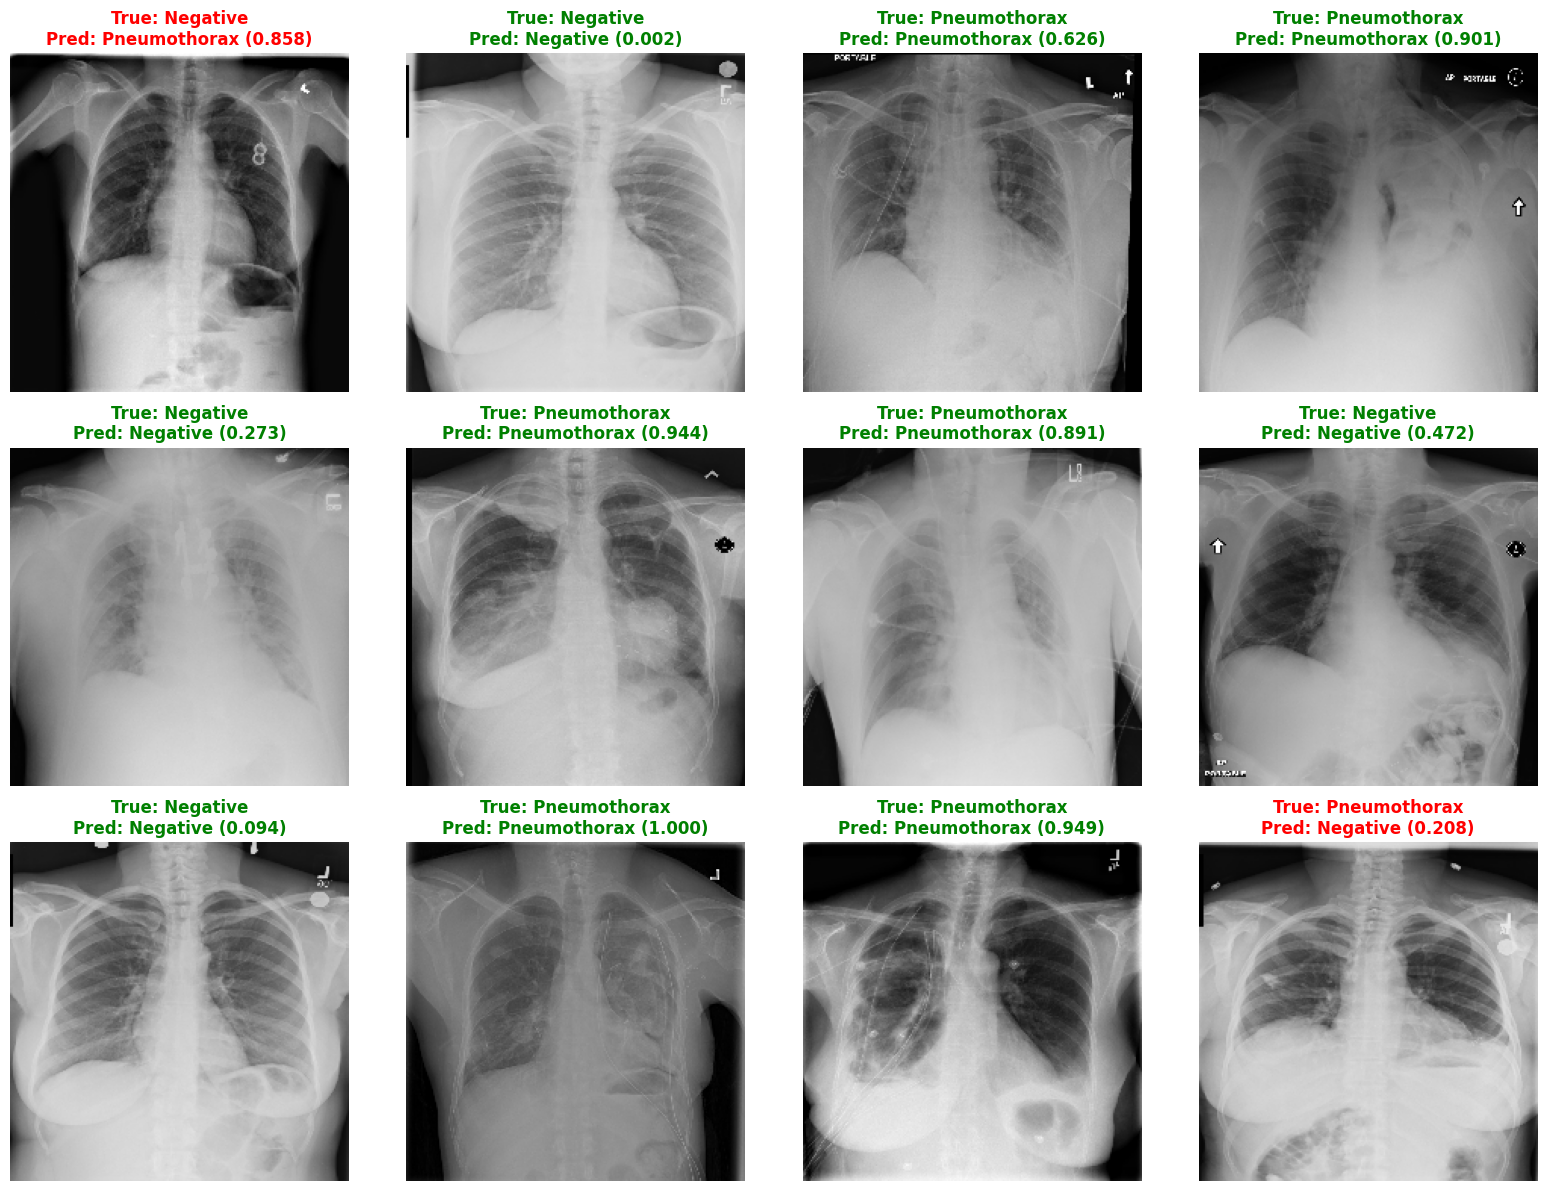

In [35]:
# ============================================================================
# VISUALIZE PREDICTIONS - FIXED
# ============================================================================

def visualize_predictions(test_df, y_pred_probs, n_samples=12):
    """Visualize sample predictions"""
    # Get sample indices
    indices = np.random.choice(len(test_df), n_samples, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, img_idx in enumerate(indices):
        img_path = test_df.iloc[img_idx]['path']
        true_label = test_df.iloc[img_idx]['binary_label']  # FIXED: Use 'binary_label'
        pred_prob = y_pred_probs[img_idx]  # FIXED: Remove [0] since it's already 1D
        pred_label = 1 if pred_prob > 0.5 else 0
        
        # Load and display image
        img = keras.preprocessing.image.load_img(img_path, target_size=(224,224))
        img_array = keras.preprocessing.image.img_to_array(img)
        
        axes[idx].imshow(img_array.astype('uint8'))
        
        # Create title with prediction info
        true_class = "Pneumothorax" if true_label == 1 else "Negative"
        pred_class = "Pneumothorax" if pred_label == 1 else "Negative"
        color = 'green' if true_label == pred_label else 'red'
        
        title = f"True: {true_class}\nPred: {pred_class} ({pred_prob:.3f})"
        axes[idx].set_title(title, color=color, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('./output/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Get predictions on test set first
print("Generating predictions on test set...")
test_predictions = model.predict(test_dataset, verbose=1)
test_pred_probs = test_predictions.flatten()  # Already 1D

print(f"Test predictions shape: {test_pred_probs.shape}")
print(f"Test dataframe shape: {test_df.shape}")

# Visualize predictions
visualize_predictions(test_df.reset_index(drop=True), test_pred_probs)

In [29]:
# Load best model
model = keras.models.load_model('./output/conv5_best.keras')

# Evaluate on val and test
val_metrics = model.evaluate(val_dataset)
test_metrics = model.evaluate(test_dataset)

print(f"Val AUC: {val_metrics}")
print(f"Test AUC: {test_metrics}")

34/34 [==============================] - 2s 72ms/step - loss: 0.5804 - binary_accuracy: 0.7955 - auc: 0.8632
Val AUC: [0.5786005854606628, 0.7839622497558594, 0.8612460494041443]
Test AUC: [0.5803899168968201, 0.795475959777832, 0.8632252812385559]


In [32]:
# Evaluate on test set
test_results = model.evaluate(test_dataset, verbose=1)
print(f"\nTest set results:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Binary Accuracy: {test_results[1]:.4f}")
print(f"  AUC: {test_results[2]:.4f}")

34/34 [==============================] - 3s 78ms/step - loss: 0.5804 - binary_accuracy: 0.7955 - auc: 0.8632

Test set results:
  Loss: 0.5804
  Binary Accuracy: 0.7955
  AUC: 0.8632
